# ECON4002 — Week 7: Producer Theory I: Technology & Costs R Code

**University of Western Australia**  
*R implementations for production functions, isoquants, cost minimization, and cost functions*

---

## Key Formulae

Profit maximisation: $\max \pi = pf(L,K) - wL - rK$. Isoquant: $f(L,K) = \bar{Q}$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 7 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 7: Producer Theory I: Technology & Costs R Code — ready!\n')

Week 7: Producer Theory I: Technology & Costs R Code — ready!


## Production Functions

### W7-CS01 — Cobb-Douglas Production Function

> **Note:** f(L,K) = A·L^α·K^β where A is total factor productivity

In [ ]:
# Cobb-Douglas production function
cobb_douglas <- function(L, K, A = 1, alpha = 0.5, beta = 0.5) {
  y <- A * L^alpha * K^beta
  return(y)
}

# Test
L <- 100; K <- 50
y <- cobb_douglas(L, K, A = 10, alpha = 0.4, beta = 0.6)
cat('Output:', round(y, 2))

### W7-CS02 — Marginal and Average Products

> **Note:** For Cobb-Douglas: MP_L = α·AP_L, so MP_L/AP_L = α

In [ ]:
# Marginal and average products for Cobb-Douglas
product_analysis <- function(L, K, A = 1, alpha = 0.5, beta = 0.5) {
  y <- cobb_douglas(L, K, A, alpha, beta)
  
  # Marginal products
  MP_L <- alpha * A * L^(alpha-1) * K^beta
  MP_K <- beta * A * L^alpha * K^(beta-1)
  
  # Average products
  AP_L <- y / L
  AP_K <- y / K
  
  return(list(
    output = y,
    MP_L = MP_L, MP_K = MP_K,
    AP_L = AP_L, AP_K = AP_K,
    MP_L_over_AP_L = MP_L / AP_L  # Should equal alpha
  ))
}

# Test
result <- product_analysis(100, 50, A = 10, alpha = 0.4, beta = 0.6)
cat('MP_L:', round(result$MP_L, 3), '\n')
cat('AP_L:', round(result$AP_L, 3), '\n')
cat('MP_L/AP_L:', round(result$MP_L_over_AP_L, 3), '(should = α = 0.4)')

## Isoquants

### W7-CS03 — Plot Isoquants

> **Note:** Isoquant: K = (y/(A·L^α))^(1/β). Curves are convex to origin.

In [ ]:
# Plot isoquants for Cobb-Douglas
plot_isoquants <- function(A = 1, alpha = 0.5, beta = 0.5, y_levels = c(50, 100, 150)) {
  L_seq <- seq(1, 200, length = 200)
  
  plot(NULL, xlim = c(0, 200), ylim = c(0, 200),
       xlab = 'Labor (L)', ylab = 'Capital (K)',
       main = 'Isoquant Map')
  
  colors <- c('blue', 'green', 'red')
  
  for (i in seq_along(y_levels)) {
    y <- y_levels[i]
    # Solve f(L,K) = y for K: K = (y/(A·L^α))^(1/β)
    K_seq <- (y / (A * L_seq^alpha))^(1/beta)
    K_seq[K_seq > 200] <- NA
    lines(L_seq, K_seq, col = colors[i], lwd = 2)
  }
  
  legend('topright', paste('y =', y_levels), col = colors, lwd = 2)
  grid()
}

plot_isoquants(A = 1, alpha = 0.5, beta = 0.5, y_levels = c(5, 10, 15))

### W7-CS04 — MRTS Calculation and Visualization

> **Note:** MRTS = (α/β)(K/L) decreases as we move down the isoquant (more L, less K)

In [ ]:
# Calculate MRTS for Cobb-Douglas
MRTS_CD <- function(L, K, alpha = 0.5, beta = 0.5) {
  mrts <- (alpha / beta) * (K / L)
  return(mrts)
}

# Visualize MRTS along an isoquant
plot_mrts <- function(A = 1, alpha = 0.5, beta = 0.5, y = 10) {
  L_seq <- seq(5, 150, length = 100)
  K_seq <- (y / (A * L_seq^alpha))^(1/beta)
  mrts_seq <- MRTS_CD(L_seq, K_seq, alpha, beta)
  
  par(mfrow = c(1, 2))
  
  # Isoquant
  plot(L_seq, K_seq, type = 'l', lwd = 2, col = 'blue',
       xlab = 'L', ylab = 'K', main = paste('Isoquant at y =', y))
  # Add tangent lines at a few points
  for (idx in c(20, 50, 80)) {
    L0 <- L_seq[idx]; K0 <- K_seq[idx]
    slope <- -mrts_seq[idx]
    abline(a = K0 - slope * L0, b = slope, col = 'gray', lty = 2)
    points(L0, K0, pch = 19, col = 'red')
  }
  grid()
  
  # MRTS as function of L
  plot(L_seq, mrts_seq, type = 'l', lwd = 2, col = 'green',
       xlab = 'L', ylab = 'MRTS', main = 'Diminishing MRTS')
  grid()
  
  par(mfrow = c(1, 1))
}

plot_mrts(A = 1, alpha = 0.5, beta = 0.5, y = 10)

## Returns To Scale

### W7-CS05 — Returns to Scale Analysis

> **Note:** RTS determined by α + β: = 1 (CRS), > 1 (IRS), < 1 (DRS)

In [ ]:
# Analyze returns to scale
returns_to_scale <- function(A = 1, alpha = 0.5, beta = 0.5, t = 2) {
  L <- 10; K <- 10
  
  # Original output
  y_original <- cobb_douglas(L, K, A, alpha, beta)
  
  # Scaled output
  y_scaled <- cobb_douglas(t * L, t * K, A, alpha, beta)
  
  # Compare
  rts_ratio <- y_scaled / (t * y_original)
  sum_exponents <- alpha + beta
  
  cat('Original output:', round(y_original, 2), '\n')
  cat('Scaled output (t=', t, '):', round(y_scaled, 2), '\n')
  cat('t × original:', round(t * y_original, 2), '\n')
  cat('Ratio:', round(rts_ratio, 3), '\n')
  cat('α + β =', sum_exponents, '\n')
  
  if (abs(sum_exponents - 1) < 0.01) {
    cat('Returns to Scale: CONSTANT (CRS)\n')
  } else if (sum_exponents > 1) {
    cat('Returns to Scale: INCREASING (IRS)\n')
  } else {
    cat('Returns to Scale: DECREASING (DRS)\n')
  }
}

# Test different cases
cat('=== CRS (α + β = 1) ===\n')
returns_to_scale(alpha = 0.4, beta = 0.6)

cat('\n=== IRS (α + β > 1) ===\n')
returns_to_scale(alpha = 0.6, beta = 0.6)

cat('\n=== DRS (α + β < 1) ===\n')
returns_to_scale(alpha = 0.3, beta = 0.4)

## Cost Minimization

### W7-CS06 — Cost Minimization - Analytical

> **Note:** At optimum: MRTS = w/r. For CRS Cobb-Douglas, solve analytically.

In [ ]:
# Analytical cost minimization for Cobb-Douglas (CRS case)
cost_minimize_CD <- function(w, r, y, alpha = 0.5) {
  beta <- 1 - alpha  # Assume CRS
  
  # From MRTS = w/r: K/L = (α/β)(w/r)⁻¹ = (β/α)(w/r)
  # Wait, let's be careful: MRTS = MP_L/MP_K = (α/β)(K/L) = w/r
  # So K/L = (β/α)(w/r)
  KL_ratio <- (beta / alpha) * (w / r)
  
  # From L^α K^β = y with K = KL_ratio × L:
  # L^α (KL_ratio × L)^β = y
  # L^(α+β) × KL_ratio^β = y
  # L = (y / KL_ratio^β)^(1/(α+β))
  L_star <- (y / (KL_ratio^beta))^(1 / (alpha + beta))
  K_star <- KL_ratio * L_star
  
  # Cost
  C_star <- w * L_star + r * K_star
  
  return(list(
    L_star = L_star,
    K_star = K_star,
    C_star = C_star,
    KL_ratio = KL_ratio
  ))
}

# Test
result <- cost_minimize_CD(w = 10, r = 20, y = 100, alpha = 0.5)
cat('Optimal L*:', round(result$L_star, 2), '\n')
cat('Optimal K*:', round(result$K_star, 2), '\n')
cat('Minimum Cost:', round(result$C_star, 2), '\n')
cat('K/L ratio:', round(result$KL_ratio, 2))

### W7-CS07 — Cost Minimization - Numerical (General)

> **Note:** Penalty method works for any production function. Verify output ≈ target y.

In [ ]:
# Numerical cost minimization using optim
cost_minimize_numerical <- function(w, r, y, prod_fn, L_init = 10, K_init = 10) {
  # Objective: minimize cost subject to output constraint
  # Use penalty method: minimize wL + rK + penalty*(y - f(L,K))²
  
  objective <- function(x, penalty = 10000) {
    L <- x[1]; K <- x[2]
    if (L <= 0 || K <= 0) return(1e10)
    cost <- w * L + r * K
    output <- prod_fn(L, K)
    violation <- (y - output)^2
    return(cost + penalty * violation)
  }
  
  result <- optim(c(L_init, K_init), objective, method = 'L-BFGS-B',
                  lower = c(0.1, 0.1))
  
  L_star <- result$par[1]
  K_star <- result$par[2]
  
  return(list(
    L_star = L_star,
    K_star = K_star,
    C_star = w * L_star + r * K_star,
    output_check = prod_fn(L_star, K_star)
  ))
}

# Test with CES production function
CES_fn <- function(L, K, A = 1, delta = 0.5, rho = 0.5) {
  A * (delta * L^rho + (1 - delta) * K^rho)^(1/rho)
}

result <- cost_minimize_numerical(w = 10, r = 20, y = 100,
                                   prod_fn = function(L, K) CES_fn(L, K))
cat('L*:', round(result$L_star, 2), '\n')
cat('K*:', round(result$K_star, 2), '\n')
cat('Cost:', round(result$C_star, 2), '\n')
cat('Output check:', round(result$output_check, 2))

## Cost Function

### W7-CS08 — Cost Function for Cobb-Douglas

> **Note:** For CRS Cobb-Douglas: C(w,r,y) = κ·w^α·r^(1-α)·y (linear in y)

In [ ]:
# Cobb-Douglas cost function (CRS case: α + β = 1)
cost_function_CD <- function(w, r, y, alpha = 0.5) {
  beta <- 1 - alpha
  # C(w,r,y) = κ × w^α × r^β × y where κ is a constant
  kappa <- (alpha^(-alpha)) * ((1-alpha)^(-(1-alpha)))
  C <- kappa * w^alpha * r^beta * y
  return(C)
}

# Verify against direct calculation
w <- 10; r <- 20; y <- 100; alpha <- 0.5

C_formula <- cost_function_CD(w, r, y, alpha)
C_direct <- cost_minimize_CD(w, r, y, alpha)$C_star

cat('From cost function:', round(C_formula, 2), '\n')
cat('From direct minimization:', round(C_direct, 2), '\n')
cat('Match:', abs(C_formula - C_direct) < 0.1)

### W7-CS09 — Verify Shephard's Lemma

> **Note:** Shephard's Lemma: ∂C/∂w = L*, ∂C/∂r = K*. Follows from envelope theorem.

In [ ]:
# Verify Shephard's Lemma: ∂C/∂w = L*, ∂C/∂r = K*
verify_shephard <- function(w, r, y, alpha = 0.5, h = 1e-6) {
  # Numerical derivatives of cost function
  dC_dw <- (cost_function_CD(w + h, r, y, alpha) - 
            cost_function_CD(w - h, r, y, alpha)) / (2 * h)
  dC_dr <- (cost_function_CD(w, r + h, y, alpha) - 
            cost_function_CD(w, r - h, y, alpha)) / (2 * h)
  
  # Direct conditional demands
  demands <- cost_minimize_CD(w, r, y, alpha)
  
  cat('=== Shephard\'s Lemma Verification ===\n')
  cat('∂C/∂w =', round(dC_dw, 3), ', L* =', round(demands$L_star, 3), '\n')
  cat('∂C/∂r =', round(dC_dr, 3), ', K* =', round(demands$K_star, 3), '\n')
  cat('\nShephard\'s Lemma verified:', 
      abs(dC_dw - demands$L_star) < 0.1 && abs(dC_dr - demands$K_star) < 0.1)
}

verify_shephard(w = 10, r = 20, y = 100, alpha = 0.4)

## Cost Curves

### W7-CS10 — Short-Run Cost Curves

> **Note:** SR costs: TC = VC + FC. MC passes through min of both AC and AVC.

In [ ]:
# Short-run cost curves with fixed capital
short_run_costs <- function(w, r, K_bar, A = 1, alpha = 0.5, beta = 0.5) {
  # With K fixed, solve for L: y = A·L^α·K_bar^β → L = (y/(A·K_bar^β))^(1/α)
  
  y_seq <- seq(1, 200, length = 100)
  
  L_seq <- (y_seq / (A * K_bar^beta))^(1/alpha)
  
  VC <- w * L_seq           # Variable cost
  FC <- r * K_bar           # Fixed cost
  TC <- VC + FC             # Total cost
  
  AVC <- VC / y_seq         # Average variable cost
  AFC <- FC / y_seq         # Average fixed cost
  AC <- TC / y_seq          # Average cost
  MC <- w * (1/alpha) * (y_seq / (A * K_bar^beta))^((1-alpha)/alpha) / (A * K_bar^beta)^(1/alpha)
  # Simplified: MC = (w/α) × L^(1-α)/A·K^β = (w/α) × (y^(1-α))/(A·K^β)^(1/α) × A^(-1)
  # Actually easier: MC = d(TC)/dy
  MC <- diff(TC) / diff(y_seq)
  MC <- c(MC[1], MC)  # Pad to same length
  
  return(data.frame(y = y_seq, TC = TC, VC = VC, FC = FC, 
                    AC = AC, AVC = AVC, AFC = AFC, MC = MC))
}

# Calculate and plot
costs <- short_run_costs(w = 20, r = 10, K_bar = 100, A = 10, alpha = 0.5, beta = 0.5)

par(mfrow = c(1, 2))

# Total costs
plot(costs$y, costs$TC, type = 'l', lwd = 2, col = 'black',
     xlab = 'Output (y)', ylab = '$', main = 'Total Costs')
lines(costs$y, costs$VC, lwd = 2, col = 'blue', lty = 2)
abline(h = costs$FC[1], col = 'red', lty = 3)
legend('topleft', c('TC', 'VC', 'FC'), col = c('black', 'blue', 'red'),
       lty = c(1, 2, 3), lwd = 2)
grid()

# Average and marginal costs
plot(costs$y, costs$AC, type = 'l', lwd = 2, col = 'black',
     xlab = 'Output (y)', ylab = '$', main = 'Unit Costs',
     ylim = c(0, max(costs$AC) * 1.5))
lines(costs$y, costs$AVC, lwd = 2, col = 'blue', lty = 2)
lines(costs$y, costs$MC, lwd = 2, col = 'red')
legend('topright', c('AC', 'AVC', 'MC'), col = c('black', 'blue', 'red'),
       lty = c(1, 2, 1), lwd = 2)
grid()

par(mfrow = c(1, 1))

### W7-CS11 — Long-Run Cost Envelope

> **Note:** LR cost is the lower envelope of SR cost curves. At each y, optimal K̄ is chosen.

In [ ]:
# Long-run cost as envelope of short-run costs
plot_lr_envelope <- function(w = 20, r = 10, A = 10, alpha = 0.5, beta = 0.5) {
  y_seq <- seq(1, 200, length = 200)
  K_bar_values <- c(25, 50, 100, 150, 200)
  colors <- rainbow(length(K_bar_values))
  
  plot(NULL, xlim = c(0, 200), ylim = c(0, 5000),
       xlab = 'Output (y)', ylab = 'Total Cost',
       main = 'Long-Run Cost Envelope')
  
  # Plot short-run cost curves for different K_bar
  all_sr_costs <- list()
  for (i in seq_along(K_bar_values)) {
    K_bar <- K_bar_values[i]
    L_seq <- (y_seq / (A * K_bar^beta))^(1/alpha)
    TC <- w * L_seq + r * K_bar
    lines(y_seq, TC, col = colors[i], lwd = 1, lty = 2)
    all_sr_costs[[i]] <- TC
  }
  
  # Long-run cost (minimum over all SR curves)
  lr_cost <- sapply(1:length(y_seq), function(j) {
    min(sapply(all_sr_costs, function(tc) tc[j]))
  })
  lines(y_seq, lr_cost, col = 'black', lwd = 3)
  
  legend('topleft', c('Long-run C(y)', paste('SR, K̄ =', K_bar_values)),
         col = c('black', colors), lwd = c(3, rep(1, length(K_bar_values))),
         lty = c(1, rep(2, length(K_bar_values))))
  grid()
}

plot_lr_envelope()

## Applications

### W7-CS12 — Agricultural Cost Analysis

> **Note:** Complete analysis: returns to scale, optimal inputs, costs at different outputs.

In [ ]:
# Complete agricultural cost analysis
farm_cost_analysis <- function(w_labor = 25, r_machinery = 50, 
                                A = 100, alpha = 0.6, beta = 0.4,
                                output_levels = c(500, 1000, 1500)) {
  cat('=== Farm Cost Analysis ===\n')
  cat('Wage rate: $', w_labor, '/hour\n')
  cat('Machinery rental: $', r_machinery, '/hour\n')
  cat('Technology: y = ', A, '·L^', alpha, '·K^', beta, '\n\n', sep = '')
  
  # Check returns to scale
  rts <- alpha + beta
  rts_type <- ifelse(abs(rts - 1) < 0.01, 'Constant', 
                     ifelse(rts > 1, 'Increasing', 'Decreasing'))
  cat('Returns to scale: α + β =', rts, '(', rts_type, ')\n\n')
  
  for (y in output_levels) {
    result <- cost_minimize_CD(w_labor, r_machinery, y, alpha)
    
    cat('--- Output:', y, 'tonnes ---\n')
    cat('Optimal labor:', round(result$L_star, 1), 'hours\n')
    cat('Optimal machinery:', round(result$K_star, 1), 'hours\n')
    cat('Total cost: $', round(result$C_star, 0), '\n')
    cat('Average cost: $', round(result$C_star / y, 2), '/tonne\n')
    cat('K/L ratio:', round(result$KL_ratio, 2), '\n\n')
  }
}

farm_cost_analysis()

### W7-CS13 — Technology Comparison

> **Note:** Modern tech: higher TFP and different factor intensity. Compare total costs.

In [ ]:
# Compare traditional vs modern agricultural technology
compare_technologies <- function(w = 20, r = 40, y = 1000) {
  cat('=== Technology Comparison ===\n')
  cat('Output target:', y, 'units\n')
  cat('Wage: $', w, ', Capital rental: $', r, '\n\n')
  
  # Traditional: labor-intensive
  trad_alpha <- 0.7; trad_beta <- 0.3; trad_A <- 1
  
  # Modern: capital-intensive with higher TFP
  mod_alpha <- 0.3; mod_beta <- 0.7; mod_A <- 1.5
  
  # Traditional technology
  # Need to adjust for non-CRS
  trad_result <- cost_minimize_numerical(
    w, r, y, 
    prod_fn = function(L, K) trad_A * L^trad_alpha * K^trad_beta
  )
  
  # Modern technology
  mod_result <- cost_minimize_numerical(
    w, r, y,
    prod_fn = function(L, K) mod_A * L^mod_alpha * K^mod_beta
  )
  
  cat('TRADITIONAL (labor-intensive):\n')
  cat('  L*:', round(trad_result$L_star, 1), '\n')
  cat('  K*:', round(trad_result$K_star, 1), '\n')
  cat('  Cost: $', round(trad_result$C_star, 0), '\n')
  cat('  K/L:', round(trad_result$K_star / trad_result$L_star, 2), '\n\n')
  
  cat('MODERN (capital-intensive, higher TFP):\n')
  cat('  L*:', round(mod_result$L_star, 1), '\n')
  cat('  K*:', round(mod_result$K_star, 1), '\n')
  cat('  Cost: $', round(mod_result$C_star, 0), '\n')
  cat('  K/L:', round(mod_result$K_star / mod_result$L_star, 2), '\n\n')
  
  savings <- trad_result$C_star - mod_result$C_star
  cat('Cost savings from modern tech: $', round(savings, 0), 
      ' (', round(100 * savings / trad_result$C_star, 1), '%)\n', sep = '')
}

compare_technologies()

## Toolkit

### W7-CS14 — Complete Producer Theory Toolkit

> **Note:** Reusable toolkit for production and cost analysis. Import into other scripts.

In [ ]:
# Complete toolkit for producer theory analysis
producer_toolkit <- list(
  
  # Production functions
  cobb_douglas = function(L, K, A = 1, alpha = 0.5, beta = 0.5) {
    A * L^alpha * K^beta
  },
  
  leontief = function(L, K, a = 1, b = 1) {
    min(L/a, K/b)
  },
  
  ces = function(L, K, A = 1, delta = 0.5, rho = 0.5) {
    A * (delta * L^rho + (1-delta) * K^rho)^(1/rho)
  },
  
  # Marginal products
  MP_L_CD = function(L, K, A = 1, alpha = 0.5, beta = 0.5) {
    alpha * A * L^(alpha-1) * K^beta
  },
  
  MP_K_CD = function(L, K, A = 1, alpha = 0.5, beta = 0.5) {
    beta * A * L^alpha * K^(beta-1)
  },
  
  # MRTS
  MRTS_CD = function(L, K, alpha = 0.5, beta = 0.5) {
    (alpha/beta) * (K/L)
  },
  
  # Cost minimization
  cost_min_CD = function(w, r, y, alpha = 0.5) {
    beta <- 1 - alpha
    KL <- (beta/alpha) * (w/r)
    L_star <- (y / (KL^beta))^(1/(alpha+beta))
    K_star <- KL * L_star
    C <- w * L_star + r * K_star
    list(L = L_star, K = K_star, C = C)
  },
  
  # Cost function
  cost_fn_CD = function(w, r, y, alpha = 0.5) {
    beta <- 1 - alpha
    kappa <- alpha^(-alpha) * beta^(-beta)
    kappa * w^alpha * r^beta * y
  }
)

# Usage example
cat('=== Producer Toolkit Demo ===\n')
L <- 50; K <- 100; w <- 15; r <- 25; y <- 80; alpha <- 0.4

cat('\nProduction:', round(producer_toolkit$cobb_douglas(L, K, alpha = alpha, beta = 0.6), 2))
cat('\nMP_L:', round(producer_toolkit$MP_L_CD(L, K, alpha = alpha, beta = 0.6), 3))
cat('\nMRTS:', round(producer_toolkit$MRTS_CD(L, K, alpha = alpha, beta = 0.6), 3))
opt <- producer_toolkit$cost_min_CD(w, r, y, alpha)
cat('\nOptimal L*:', round(opt$L, 2), ', K*:', round(opt$K, 2), ', C*:', round(opt$C, 2))

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

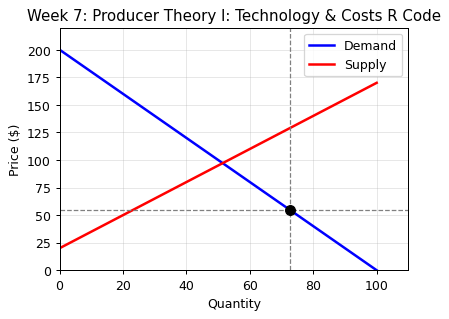

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.